# Импорт библиотек и фиксация констант

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.feature_selection import VarianceThreshold


In [37]:
RANDOM_STATE = 42

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка и первичный осмотр данных

In [38]:
# Загружаем Excel-файл
df = pd.read_excel('coursework_ml_data.xlsx')

# Проверяем размерность (должно быть 1001 на 213)
print(f"Размер датасета: {df.shape}")

Размер датасета: (1001, 214)


In [39]:
df

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,...,0,0,0,0,0,0,0,0,0,0
997,997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,...,0,0,0,0,0,0,0,0,0,0
998,998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,...,1,0,0,0,0,0,0,0,0,0
999,999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,...,0,0,0,0,0,0,0,0,0,0


In [40]:
# Удаление лишнего столбца
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Новая размерность: {df.shape}")

Новая размерность: (1001, 213)


**Вывод:** Данные успешно считаны и ощичены от технических деталей (лишний столюец с индексами).

### Первичный обзор

In [41]:
# Копируем, чтобы не было предупреждения о фрагментации
df = df.copy()

In [42]:
# Транспонированный вывод первых строк
df.head(3).T

,0,1,2
"IC50, mM",6.239374,0.771831,223.808778
"CC50, mM",175.482382,5.402819,161.142320
SI,28.125000,7.000000,0.720000
MaxAbsEStateIndex,5.094096,3.961417,2.627117
MaxEStateIndex,5.094096,3.961417,2.627117
...,...,...,...
fr_thiazole,0.000000,0.000000,0.000000
fr_thiocyan,0.000000,0.000000,0.000000
fr_thiophene,0.000000,0.000000,0.000000
fr_unbrch_alkane,3.000000,3.000000,3.000000


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


Признаков слишком много, чтобы ихвывести все на экран. Здесь мы видим, что они все числовые, половина имеет тип `float`, половина `int`.

## Поиск пропущенных значений и дубликатов

In [44]:
# Проверка наличия пропущенных значений (NaN)
missing_values = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100
# Объединяем в один датафрейм для наглядности
missing_df = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Процент пропусков (%)': missing_percentage
})

# Выводим только те признаки, где есть пропуски (если они есть)
missing_df[missing_df['Количество пропусков'] > 0]

,Количество пропусков,Процент пропусков (%)
MaxPartialCharge,3,0.2997
MinPartialCharge,3,0.2997
MaxAbsPartialCharge,3,0.2997
MinAbsPartialCharge,3,0.2997
BCUT2D_MWHI,3,0.2997
BCUT2D_MWLOW,3,0.2997
BCUT2D_CHGHI,3,0.2997
BCUT2D_CHGLO,3,0.2997
BCUT2D_LOGPHI,3,0.2997
BCUT2D_LOGPLOW,3,0.2997


In [45]:
# Фильтруем строки с пропусками и оставляем только проблемные колонки
df_miss = df[df.isna().any(axis=1)]
df_miss.loc[:, df_miss.isna().any()]


,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# Находим имена всех колонок, где есть пропуски
missing_cols = df.columns[df.isna().any()].tolist()

# Добавляем к ним целевые переменные для анализа контента
target_cols = ['IC50, mM', 'CC50, mM', 'SI']
all_cols_to_analyze = missing_cols + target_cols

# Выводим статистику describe (транспонированную для удобства)
df[all_cols_to_analyze].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
MaxPartialCharge,998.0,0.236,0.129,-0.017,0.118,0.251,0.336,0.573
MinPartialCharge,998.0,-0.407,0.076,-0.744,-0.478,-0.394,-0.354,-0.085
MaxAbsPartialCharge,998.0,0.416,0.072,0.085,0.361,0.426,0.478,0.744
MinAbsPartialCharge,998.0,0.228,0.120,0.002,0.117,0.251,0.331,0.507
BCUT2D_MWHI,998.0,23.197,14.529,14.514,16.367,16.564,32.092,126.913
BCUT2D_MWLOW,998.0,9.793,0.461,0.931,9.689,9.715,9.981,10.709
BCUT2D_CHGHI,998.0,2.472,0.162,1.834,2.380,2.506,2.591,2.822
BCUT2D_CHGLO,998.0,-2.347,0.169,-2.722,-2.476,-2.359,-2.236,-1.714
BCUT2D_LOGPHI,998.0,2.473,0.157,1.932,2.357,2.485,2.613,2.791
BCUT2D_LOGPLOW,998.0,-2.403,0.177,-2.786,-2.529,-2.396,-2.324,-1.648


In [47]:
# Выводим значения целевых переменных только для строк с пропусками (78, 79, 80)
targets = ['IC50, mM', 'CC50, mM', 'SI']
df.loc[[78, 79, 80], targets].round(3)


,"IC50, mM","CC50, mM",SI
78,1127.095,1127.095,1.000
79,25.172,1878.492,74.627
80,1199.175,1199.175,1.000


### Обоснование удаления пропусков

В ходе EDA было выявлено 3 строки с пропущенными значениями (индексы 78, 79, 80). Пропуски локализованы в дескрипторах частичных зарядов (`MaxPartialCharge`, `MinPartialCharge` и др.) и топологических индексах (`BCUT2D_*`). 

Принято решение **удалить данные строки** из выборки по следующим причинам:

1. **Технический характер пропусков:** Появление `NaN` вызвано сбоем алгоритма расчета электронных свойств (например, несходимостью квантово-химического метода для специфических структур).
2. **Аномальный характер таргетов:** Объекты 78 и 80 обладают экстремально высокими значениями `IC50` и `CC50` (~1127 и ~1199 мМ при медианах 46.5 и 411.0 мМ). Искусственное заполнение дескрипторов медианой создаст противоречивый «шум» в признаковом пространстве и снизит качество регрессионных моделей.
3. **Безопасный объем потери данных:** Удаление 3 строк из 1001 составляет **всего ~0.3% от датасета**, что никак не влияет на репрезентативность выборки, но гарантирует чистоту признаков для обучения моделей.


#### -=Врезка, физический контекст=-

**Химический смысл дескрипторов с пропусками**

Данные показатели **фундаментально важны** для хемоинформатики и QSAR-моделирования (*количественного соотношения структура—активность*). Они описывают ключевые физико-химические свойства исследуемых молекул:

* **Частичные заряды (`PartialCharge`)**: 
  Отражают электронную плотность на атомах. Модели машинного обучения используют их, чтобы оценить способность молекулы образовывать водородные связи, её полярность и электростатическое взаимодействие с карманом белка-мишени. Это напрямую влияет на биологическую активность (`IC50`).

* **BCUT2D-дескрипторы**: 
  Это топологические дескрипторы, представляющие собой собственные значения матриц молекулярного графа. Они одновременно кодируют:
  * Геометрическую форму молекулы (её связность);
  * Её атомные свойства: массу (`MW`), полярность (`CHG`) и липофильность (`LOGP`).
  
  *Пример:* Дескрипторы вроде `BCUT2D_LOGPLOW` и `BCUT2D_CHGHI` — важнейшие параметры, по которым модели оценивают способность вещества проникать через клеточные мембраны. Если вещество не способно проникнуть внутрь клетки, оно не покажет ожидаемую биологическую активность, что напрямую исказит значения `IC50` и `CC50`.


**Химическая ценность объекта №79 (Индекс селективности)**

Строка под индексом 79 представляет особый интерес с точки зрения медицинской химии из-за аномально высокого **индекса селективности ($SI \approx 74.63$)**.

* **Что такое SI (Selectivity Index):** 
  Это отношение токсичной концентрации к терапевтической ($SI = CC50 / IC50$). Он показывает терапевтическое окно препарата. Чем выше этот показатель, тем безопаснее вещество для здоровых клеток при уничтожении мишени (например, вируса или опухоли). 
  
* **В чем ценность этой молекулы:**
  Значение $SI > 8$ в фармакологии считается общепринятым порогом для отбора перспективных соединений-лидеров (lead compounds). Объект 79 превосходит этот порог почти в 10 раз ($SI \approx 74.63$), обладая высокой активностью ($IC50 \approx 25.17$ мМ, что ниже медианы выборки) и экстремально низкой токсичностью ($CC50 \approx 1878.49$ мМ). 

* **Почему её все же пришлось удалить:**
  Несмотря на высокую биологическую ценность, технический сбой расчета дескрипторов (отсутствие данных о зарядах и топологии) делает невозможным использование этой молекулы в обучении. Искусственное «дорисовывание» (импутация) признаков для такого уникального объекта заставило бы модель искать ложные взаимосвязи, что критически опасно для её обобщающей способности.


In [48]:
# Удаляем строки и сразу переприсваиваем в df
df = df.dropna().reset_index(drop=True)

# Проверяем размерность (должно стать на 3 строки меньше)
print(f"Новый размер датасета: {df.shape}")

# Убеждаемся, что пропусков не осталось
print(f"Количество пропусков в таблице: {df.isna().sum().sum()}")


Новый размер датасета: (998, 213)
Количество пропусков в таблице: 0


*Примечание:* Если оставить старые индексы, то длина массива (998 строк) перестанет совпадать с максимальным индексом (1000). При конвертации данных в NumPy и обратно это неизбежно приведет к путанице, сдвигам в данных или ошибкам выхода за границы массива (`IndexError`). Сброс индексов делает структуру данных прозрачной.


### Поиск и анализ дубликатов


In [49]:
# Оборачиваем в функцию, чтобы можно было вызывать несколько раз
def check_chemical_duplicates(dataframe):
    """
    Функция для поиска полных и скрытых дубликатов в химическом датасете.
    """
    # Проверка полных дубликатов
    full_duplicates = dataframe.duplicated().sum()
    print(f"Полных дубликатов (совпадают все признаки и таргеты): {full_duplicates}")
    
    # Проверка дубликатов только по химическим признакам (без учета таргетов)
    target_cols = ['IC50, mM', 'CC50, mM', 'SI']
    feature_cols = [col for col in dataframe.columns if col not in target_cols]
    
    feature_duplicates = dataframe.duplicated(subset=feature_cols).sum()
    print(f"Повторяющихся молекул (одинаковые признаки, но возможно разные таргеты): {feature_duplicates}")
    
    # Вывод результатов
    if feature_duplicates > 0:
        duplicated_rows = dataframe[dataframe.duplicated(subset=feature_cols, keep=False)].sort_values(by=feature_cols[0])
        print('Первые 10 строк с дубликатами для визуального анализа:')
        display(duplicated_rows.head(10))
    else:
        print("Отлично! Скрытых дубликатов молекул в датасете не обнаружено.")


check_chemical_duplicates(df)

Полных дубликатов (совпадают все признаки и таргеты): 32
Повторяющихся молекул (одинаковые признаки, но возможно разные таргеты): 196
Первые 10 строк с дубликатами для визуального анализа:


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
899,100.000452,100.000452,1.000000,2.599352,2.599352,0.572338,0.572338,0.690593,50.625000,221.388,...,0,0,0,0,0,0,0,0,0,0
900,5.099621,100.000452,19.609389,2.599352,2.599352,0.572338,0.572338,0.690593,50.625000,221.388,...,0,0,0,0,0,0,0,0,0,0
901,5.998491,100.000452,16.670934,2.599352,2.599352,0.572338,0.572338,0.690593,50.625000,221.388,...,0,0,0,0,0,0,0,0,0,0
898,100.000452,100.000452,1.000000,2.599352,2.599352,0.572338,0.572338,0.690593,50.625000,221.388,...,0,0,0,0,0,0,0,0,0,0
897,6.000683,100.000000,16.664769,2.669444,2.669444,0.549375,0.549375,0.693897,43.105263,263.469,...,0,0,0,0,0,0,0,0,0,0
896,100.000000,100.000000,1.000000,2.669444,2.669444,0.549375,0.549375,0.693897,43.105263,263.469,...,0,0,0,0,0,0,0,0,0,0
895,100.000000,100.000000,1.000000,2.669444,2.669444,0.549375,0.549375,0.693897,43.105263,263.469,...,0,0,0,0,0,0,0,0,0,0
213,24.466747,79.272261,3.240000,4.301519,4.301519,0.567685,0.567685,0.500562,38.866667,204.357,...,0,0,0,0,0,0,0,0,0,0
214,146.800483,133.588440,0.910000,4.301519,4.301519,0.567685,0.567685,0.500562,38.866667,204.357,...,0,0,0,0,0,0,0,0,0,0
183,54.087564,257.956073,4.769231,4.688093,4.688093,0.304538,0.304538,0.786588,22.388889,240.350,...,0,0,0,0,0,0,0,0,0,0


#### Проблема дубликатов и химических «близнецов»

При поиске дубликатов мы обнаружили две разные проблемы:
1. **32 полных дубликатов** — строки, которые скопированы один в один вместе с ответами. Эти строки удаляем, иначе модель их зазубрит, и мы получим фальшивые идеальные метрики на тесте (одна строка попадёт в трейн, другая в тест, accuracy=100%).
2. **196 повторяющихся молекул с разными ответами** — это интереснее. Физико-химические свойства (дескрипторы) у них абсолютно одинаковые, а вот значения `IC50` и `CC50` заметно отличаются (например, для одной структуры в разных тестах получилось `5.09` и `100.0`). 

**Что с ними делать?**
* Просто удалить через `drop_duplicates` нельзя — Pandas наугад выкинет часть строк, и мы потеряем кучу ценных данных (почти 20% датасета!).
* Оставлять как есть тоже нельзя — модель запутается, если на одни и те же признаки ей будут подсовывать абсолютно разные ответы.

**Решение:**
Применяем стандартный для хемоинформатики подход — **агрегацию**. Схлопываем одинаковые молекулы в одну строку, а их биологические ответы (`IC50`, `CC50`, `SI`) усредняем. Это сглаживает экспериментальный шум, не дает модели запутаться и сохраняет все химические структуры для обучения.


In [50]:
# Удаляем абсолютные дубликаты (где совпадает всё, включая таргеты)
df = df.drop_duplicates().reset_index(drop=True).copy() # копируем, чтобы не было дефрагментации
df.shape

(966, 213)

In [51]:
# Список колонок-признаков (всё, кроме таргетов)
target_cols = ['IC50, mM', 'CC50, mM', 'SI']
feature_cols = [col for col in df.columns if col not in target_cols]

# Группируем по признакам молекул и усредняем их биологические таргеты
df = df.groupby(feature_cols, as_index=False)[target_cols].mean()
df = df.copy(deep=True) # копируем, чтобы не было дефрагментации

# Проверяем финальный размер таблицы
print(f"Размер датасета после очистки всех типов дубликатов: {df.shape}")

Размер датасета после очистки всех типов дубликатов: (802, 213)


/tmp/ipykernel_133784/3103674823.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.groupby(feature_cols, as_index=False)[target_cols].mean()


Предупреждение всё равно вылазит, так как метод `.groupby(...)` под капотом собирает новый датафрейм по кусочкам (столбец за столбцом), и вызов `.copy()` в самом конце уже не помогает — предупреждение вылетает внутри самого процесса группировки, поэтому избежать этого предупреждения не получается.

In [52]:
# Проверяем ещё раз на дубликаты
check_chemical_duplicates(df)

Полных дубликатов (совпадают все признаки и таргеты): 0
Повторяющихся молекул (одинаковые признаки, но возможно разные таргеты): 0
Отлично! Скрытых дубликатов молекул в датасете не обнаружено.


### Вывод

В ходе первичного обзора были выявлены пропущенные значения и эти молекулы удалены. Так как исследование затрагивает безопасность живых организмов, а пропущенных значений не много (0.3%), то заполнение медианными значениями было признано нецелесообразным и рискованным.

Были выявлены полнные дубликаты, удалены, и частичные (химия одинакова, а таргет нет), для них таргет заполнен усреднённым значением, что допустимо, так как даже в ходе одного и того же эксперимента могут быть получены разные результаты из-за шума.

# Разведочный анализ данных (EDA)


## Анализ распределений таргетных переменных

In [53]:
# Вывод статистики целевых колонок
df[['IC50, mM', 'CC50, mM', 'SI']].describe()

,"IC50, mM","CC50, mM",SI
count,802.000000,802.000000,802.000000
mean,228.611268,565.616065,30.269712
std,374.062094,582.694556,152.682825
min,0.013341,0.810833,0.060004
25%,15.086472,100.000595,1.552383
50%,57.425204,449.988753,3.625832
75%,281.168866,871.025132,13.435274
max,4128.529377,4538.976189,2685.512715


Видим, что целевые признаки имеют огромный разброс, от около нулевых значений, до нескольких тысяч. Стандартное отклонение превышает среднее значение. Для нормальизации такого рода, помогает логарифимирование. Здесь нам в первую очередь надо привести все значения IC50 и CC50 к единой системе единиц (например, молярность). Затем выполнить логарифмическую трансформацию: вычислить `pIC50 = -log10(IC50)` и `pCC50 = -log10(CC50)`. Именно на этих двух новых переменных будут обучаться модели.

Отрицательный логарифм превращает неудобные значения концентраций в простую линейную шкалу.

Зачем это нужно в машинном обучении:
* **Инверсия шкалы**: делает интерпретацию интуитивной. (Высокая активность молекулы (меньшая концентрация) дает больший `pIC50`).
* **Сжатие диапазона**: убирает разброс в миллионы раз.
* **Линеаризация**: приводит данные к нормальному распределению.
* **Стабильность**: защищает модель от влияния выбросов.

## Логарифмическая трансформация и разметка классов

In [54]:
# Переводим IC50 и CC50 из мМ в молярный логарифм (p-шкалу)
# Формула учитывает перевод мМ -> М (умножение на 10^-3 под логарифмом превращается в +3 перед ним)
df['pIC50'] = 3 - np.log10(df['IC50, mM'])
df['pCC50'] = 3 - np.log10(df['CC50, mM'])

# Считаем логарифм SI для визуализации распределения
df['log10_SI'] = np.log10(df['SI'])

# Считаем медианы для разметки задач классификации (уже по очищенным данным)
med_ic50 = df['IC50, mM'].median()
med_cc50 = df['CC50, mM'].median()
med_si = df['SI'].median()

# Создаем бинарные признаки для задач классификации (1 — превышает порог/медиану, 0 — нет)
df['class_IC50_above_med'] = (df['IC50, mM'] > med_ic50).astype(int)
df['class_CC50_above_med'] = (df['CC50, mM'] > med_cc50).astype(int)
df['class_SI_above_med'] = (df['SI'] > med_si).astype(int)
df['class_SI_above_8'] = (df['SI'] > 8).astype(int)

# Выведем новые колонки, чтобы убедиться, что всё рассчитано корректно
display( df[['IC50, mM', 'pIC50', 'CC50, mM', 'pCC50', 'SI', 'log10_SI', 'class_SI_above_8']].head() )
display( df[['IC50, mM', 'pIC50', 'CC50, mM', 'pCC50', 'SI', 'log10_SI', 'class_SI_above_8']].describe() )
df.shape

,"IC50, mM",pIC50,"CC50, mM",pCC50,SI,log10_SI,class_SI_above_8
0,3.790553,2.421297,15.320152,1.814737,4.041667,0.606560,0
1,70.633045,1.150992,894.089176,0.048619,12.658228,1.102373,1
2,18.908167,1.723351,14.559288,1.836860,0.770000,-0.113509,0
3,43.522458,1.361287,72.435979,1.140046,1.664336,0.221241,0
4,4.893349,2.310394,37.678791,1.423903,7.700000,0.886491,0


,"IC50, mM",pIC50,"CC50, mM",pCC50,SI,log10_SI,class_SI_above_8
count,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000
mean,228.611268,1.250901,565.616065,0.566965,30.269712,0.716479,0.335411
std,374.062094,0.876452,582.694556,0.657119,152.682825,0.673405,0.472429
min,0.013341,-0.615795,0.810833,-0.656958,0.060004,-1.221823,0.000000
25%,15.086472,0.551034,100.000595,0.059969,1.552383,0.190999,0.000000
50%,57.425204,1.240899,449.988753,0.346803,3.625832,0.559407,0.000000
75%,281.168866,1.821419,871.025132,0.999997,13.435274,1.128245,1.000000
max,4128.529377,4.874799,4538.976189,3.091069,2685.512715,3.429027,1.000000


(802, 220)

В соответствии с практической методикой, выполнена трансформация целевых переменных регрессии:
* Исходные концентрации `IC50` и `CC50` переведены из миллимолей ($mM$) в молярность ($M$) и трансформированы в отрицательный десятичный логарифм (`pIC50` и `pCC50`). Это решает проблему экстремальной асимметрии данных.

Также подготовлены целевые метки для 4 задач классификации:
* Созданы бинарные классы на основе медианных значений выборок для `IC50`, `CC50` и `SI`.
* Создан отдельный класс для поиска потенциальных соединений-лидеров по фармакологическому порогу селективности (`SI > 8`).


## Визуализация распределения таргетных переменных

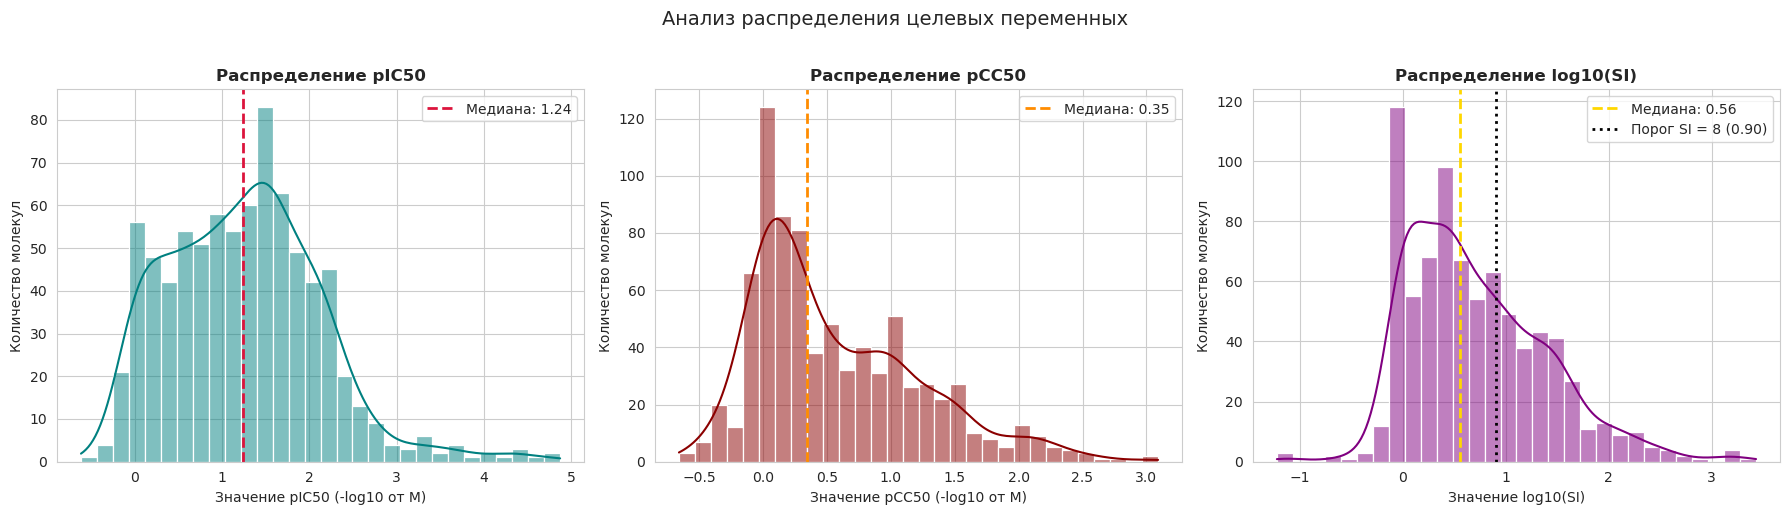

In [55]:
# Расчет порога медиан по логарифмированным данным)

med_pic50 = df['pIC50'].median()
med_pcc50 = df['pCC50'].median()
med_log_si = df['log10_SI'].median()

# Форма для графика
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График для pIC50
sns.histplot(df['pIC50'], kde=True, ax=axes[0], color='teal', bins=30)
axes[0].axvline(med_pic50, color='crimson', linestyle='--', linewidth=2, 
                label=f'Медиана: {med_pic50:.2f}')
axes[0].set_title('Распределение pIC50', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Значение pIC50 (-log10 от M)')
axes[0].set_ylabel('Количество молекул')
axes[0].legend(loc='upper right') # Выводим плашку с медианой

# График для pCC50
sns.histplot(df['pCC50'], kde=True, ax=axes[1], color='darkred', bins=30)
axes[1].axvline(med_pcc50, color='darkorange', linestyle='--', linewidth=2, 
                label=f'Медиана: {med_pcc50:.2f}')
axes[1].set_title('Распределение pCC50', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Значение pCC50 (-log10 от M)')
axes[1].set_ylabel('Количество молекул')
axes[1].legend(loc='upper right')

# График для log10(SI)
sns.histplot(df['log10_SI'], kde=True, ax=axes[2], color='purple', bins=30)
axes[2].axvline(med_log_si, color='gold', linestyle='--', linewidth=2, 
                label=f'Медиана: {med_log_si:.2f}')
# Добавим жесткий порог SI > 8 на этот же график (log10(8) ≈ 0.90)
axes[2].axvline(np.log10(8), color='black', linestyle=':', linewidth=2, 
                label='Порог SI = 8 (0.90)')
axes[2].set_title('Распределение log10(SI)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Значение log10(SI)')
axes[2].set_ylabel('Количество молекул')
axes[2].legend(loc='upper right')

fig.suptitle('Анализ распределения целевых переменных', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


После логарифмирования данные стали интуитивно понятней. Слева направо: 
* Сила препарата — чем больше, тем лучше.
* Токсичность — чем больше, тем хуже.
* Индекс безопасности ($\log_{10}(SI) = pIC_{50} - pCC_{50}$) — чем больше, тем лучше.

## Удаление константных переменных

In [56]:
# Выделяем только признаки (исключаем таргеты и вспомогательные колонки логарифмов)
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log10_SI',
                'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8']
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Задаем порог: 0.0 — удалит строго константные (std=0). 
selector = VarianceThreshold(threshold=0.00)
selector.fit(df[feature_cols])

# Получаем оставшиеся колонки
kept_features = list(df[feature_cols].columns[selector.get_support()])
removed_features = list(set(feature_cols) - set(kept_features))
print(f"Выбрано константных признаков: {len(removed_features)}")
df_removed = df[removed_features]
df_removed.head()

Выбрано константных признаков: 18


,fr_phos_ester,fr_barbitur,fr_nitroso,fr_SH,fr_isocyan,NumRadicalElectrons,fr_lactam,fr_N_O,fr_prisulfonamd,fr_isothiocyan,fr_phos_acid,SlogP_VSA9,fr_diazo,fr_dihydropyridine,fr_benzodiazepine,SMR_VSA8,fr_thiocyan,fr_azide
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [57]:
df_removed.sum()

fr_phos_ester          0
fr_barbitur            0
fr_nitroso             0
fr_SH                  0
fr_isocyan             0
NumRadicalElectrons    0
fr_lactam              0
fr_N_O                 0
fr_prisulfonamd        0
fr_isothiocyan         0
fr_phos_acid           0
SlogP_VSA9             0
fr_diazo               0
fr_dihydropyridine     0
fr_benzodiazepine      0
SMR_VSA8               0
fr_thiocyan            0
fr_azide               0
dtype: int64

Эти признаки смело удаляем.

In [58]:
# Обновляем датафрейм (сохраняя таргеты)
df = df[kept_features + exclude_cols]
print(f"Новая размерность датасета: {df.shape}")

Новая размерность датасета: (802, 202)


Обзор маловариативных признаков

In [59]:
# Выделяем только признаки (исключаем таргеты и вспомогательные колонки логарифмов)
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Задаем порог: 0.01 удалит те признаки, где 99% значений одинаковы (рекомендуется для QSAR)
selector = VarianceThreshold(threshold=0.01)
selector.fit(df[feature_cols])

# Получаем оставшиеся колонки
kept_features = list(df[feature_cols].columns[selector.get_support()])
removed_features = list(set(feature_cols) - set(kept_features))
print(f"Удалено константных признаков: {len(removed_features)}")
df_removed = df[removed_features]
df_removed.head(3)

Удалено константных признаков: 16


,fr_azo,MaxAbsPartialCharge,fr_hdrzine,MinPartialCharge,fr_tetrazole,fr_Ar_COO,fr_term_acetylene,fr_priamide,fr_urea,fr_amidine,fr_epoxide,fr_guanido,fr_nitrile,fr_oxazole,fr_HOCCN,fr_aldehyde
0,0,0.309636,0,-0.309636,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0.353704,0,-0.353704,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0.293073,0,-0.293073,0,0,0,0,0,0,0,0,0,0,0,0


In [60]:
# Вывод маловариативных признаков
df_removed.sum()

fr_azo                   7.000000
MaxAbsPartialCharge    337.186132
fr_hdrzine               3.000000
MinPartialCharge      -329.524001
fr_tetrazole             1.000000
fr_Ar_COO                1.000000
fr_term_acetylene        1.000000
fr_priamide              5.000000
fr_urea                  7.000000
fr_amidine               8.000000
fr_epoxide               5.000000
fr_guanido               2.000000
fr_nitrile               6.000000
fr_oxazole               4.000000
fr_HOCCN                 1.000000
fr_aldehyde              3.000000
dtype: float64

Все удалять точно не надо, а вот те признаки, которые встречаются у одной-двух молекул не нужны, будут только зашумливать модель.

In [61]:
# Фильтрация признаков, которые отсек VarianceThreshold(0.01)

# Задаем минимальный порог: фрагмент должен встречаться хотя бы у 2 молекул
min_molecule_threshold = 2

features_to_restore = []
features_to_drop_permanently = []

for col in removed_features:
    # Если это непрерывный признак заряда, его обязательно нужно вернуть
    if 'PartialCharge' in col:
        features_to_restore.append(col)
    # Если это химический фрагмент (fr_*), проверяем его сумму
    elif col.startswith('fr_'):
        if df_removed[col].sum() >= min_molecule_threshold:
            features_to_restore.append(col)  # Спасаем (частый фрагмент)
        else:
            features_to_drop_permanently.append(col)  # Удаляем насовсем (слишком редкий)
    else:
        # На всякий случай для остальных неопознанных признаков
        features_to_drop_permanently.append(col)

print(f"Признаков возвращено в датасет: {len(features_to_restore)}")
print(f"Признаков удалено навсегда: {len(features_to_drop_permanently)}")

# Возвращаем спасенные признаки обратно в основной список kept_features
kept_features = list(set(kept_features) | set(features_to_restore))

df_removed = df[features_to_drop_permanently]
df_removed.head(4)

Признаков возвращено в датасет: 12
Признаков удалено навсегда: 4


,fr_tetrazole,fr_Ar_COO,fr_term_acetylene,fr_HOCCN
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0


In [62]:
df_removed.sum()

fr_tetrazole         1
fr_Ar_COO            1
fr_term_acetylene    1
fr_HOCCN             1
dtype: int64

In [63]:
# Обновляем df (пересобираем его с правильным набором колонок)
df = df[kept_features + exclude_cols]
print(f"Итоговая размерность датасета после точечной фильтрации: {df.shape}")

Итоговая размерность датасета после точечной фильтрации: (802, 198)


**Подитог:** Были удалены константные признаки, которые не меняются на протяжении всего датасета, и маловариативные, в нашем случае, если этот признак встречается лишь у одной молекулы. Даже если он оказывает решающую роль, то мы никак об этом не узнаем (если эта молекула будет в train, то мы получим правило, которое никогда не применится и, наоборот, если она будет в тесте, то модель не будет знать, что с ним делать.)

## Анализ мультиколлинеарности (сильных корреляций)

In [64]:
# Считаем матрицу корреляции только для признаков
corr_matrix = df[kept_features].corr().abs()

# Выбираем верхний треугольник матрицы, чтобы не дублировать пары (А-Б и Б-А)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Разворачиваем в плоский список и сортируем по убыванию корреляции
corr_pairs = upper_tri.unstack().dropna().sort_values(ascending=False)

# Выводим топ-20 пар с корреляцией выше 0.85
high_corr_pairs = corr_pairs[corr_pairs > 0.85]
print("Топ-20 сильно скоррелированных пар признаков:")
display(high_corr_pairs.head(20))


Топ-20 сильно скоррелированных пар признаков:


fr_benzene              NumAromaticCarbocycles    1.000000
fr_COO2                 fr_COO                    1.000000
MaxAbsEStateIndex       MaxEStateIndex            1.000000
fr_phenol_noOrthoHbond  fr_phenol                 1.000000
fr_Ar_NH                fr_Nhpyrrole              1.000000
MolWt                   ExactMolWt                0.999998
HeavyAtomCount          Chi1                      0.998644
MolWt                   HeavyAtomMolWt            0.997031
HeavyAtomMolWt          ExactMolWt                0.996999
HeavyAtomCount          Chi0                      0.995977
NumValenceElectrons     Chi0                      0.994853
HeavyAtomCount          LabuteASA                 0.994256
LabuteASA               Chi1                      0.992915
Chi0n                   Chi0v                     0.992056
fr_Ar_OH                fr_phenol                 0.991140
fr_phenol_noOrthoHbond  fr_Ar_OH                  0.991140
Chi0                    Chi1                      0.9905

In [65]:
# Фильтрация мультиколлинеарности (удаление сильно скоррелированных признаков)

# Порог корреляции, выше которого признак удаляется (0.90 — золотой стандарт)
threshold = 0.90

# Находим признаки, которые нужно удалить
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

print(f"Количество удаленных избыточных признаков: {len(to_drop)}")
print(f"Примеры удаленных признаков: {to_drop[:10]}")

# Удаляем их из списка kept_features
kept_features = [col for col in kept_features if col not in to_drop]

# Обновляем наш основной датафрейм
df = df[kept_features + exclude_cols]
print(f"\nРазмерность датасета после очистки от мультиколлинеарности: {df.shape}")


Количество удаленных избыточных признаков: 44
Примеры удаленных признаков: ['Chi1', 'HeavyAtomMolWt', 'BertzCT', 'LabuteASA', 'Chi1n', 'Chi0', 'Chi1v', 'Kappa2', 'MaxAbsEStateIndex', 'MolMR']

Размерность датасета после очистки от мультиколлинеарности: (802, 154)


**Очистка от мультиколлинеарности**

В ходе корреляционного анализа обнаружено большое количество признаков-дубликатов с корреляцией выше `0.90` (вплоть до идеальных `1.00`). Например, `ExactMolWt` и `MolWt` дублируют массу, а `fr_benzene` и `NumAromaticCarbocycles` одинаково считают бензольные кольца.

Чтобы избавить модели (особенно линейные) от переобучения и "взрыва" весов, был применен алгоритм фильтрации: из каждой пары признаков с корреляцией $> 0.90$ один был удален. Это позволило сократить размерность признакового пространства без потери важной информации.


### Матрица корреляций

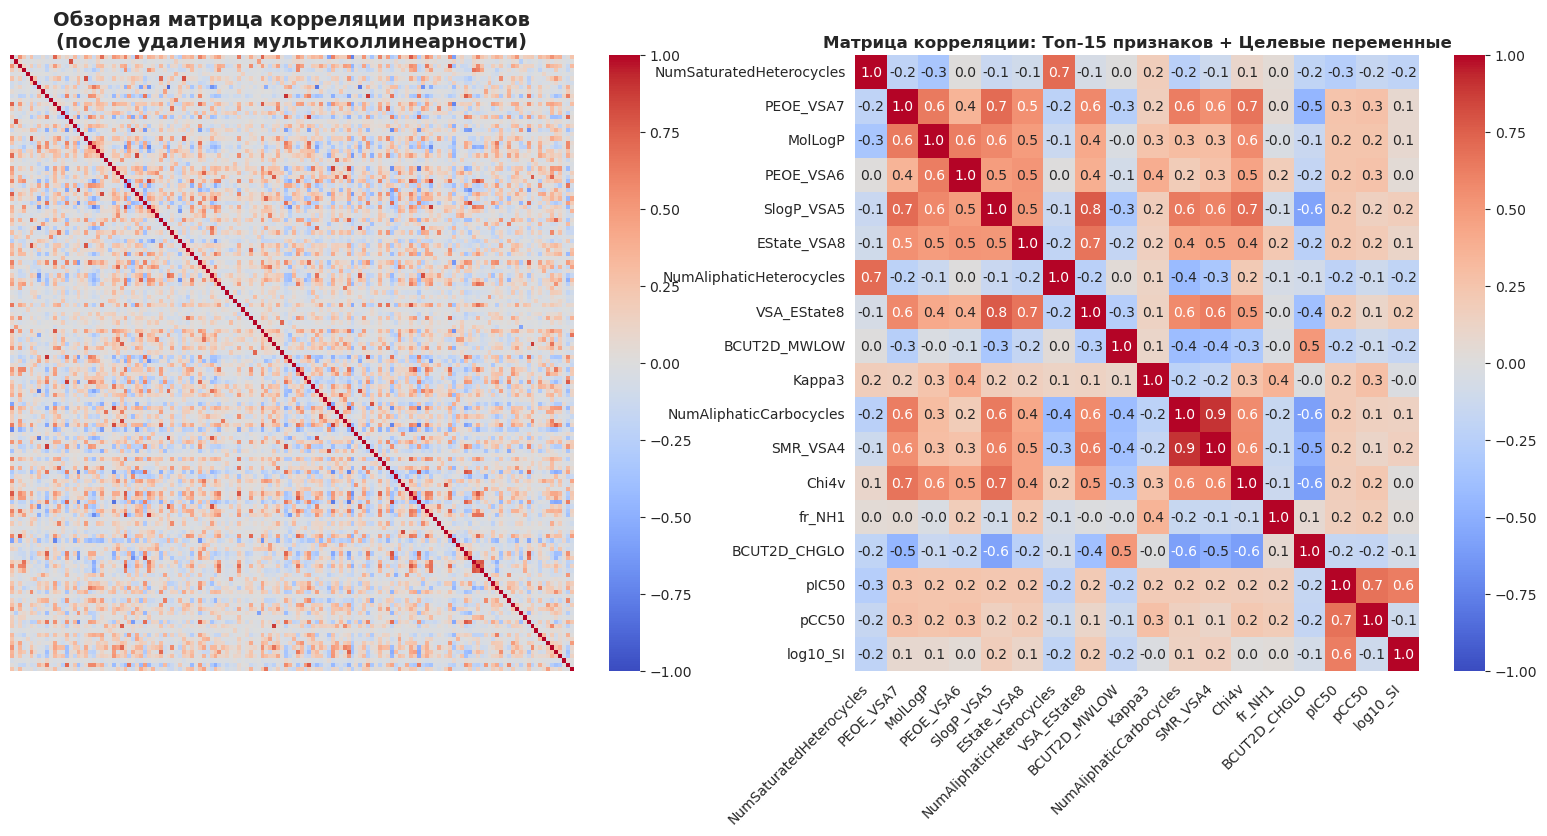

In [66]:
# Настраиваем общую сетку для двух графиков
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# График 1: Обзорная матрица корреляции для ВСЕХ оставшихся признаков
# 
# Считаем корреляцию только для признаков
features_corr = df[kept_features].corr()

sns.heatmap(features_corr, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            xticklabels=False, yticklabels=False, # Отключаем подписи, чтобы не было каши
            cbar=True, 
            ax=axes[0])
axes[0].set_title('Обзорная матрица корреляции признаков\n(после удаления мультиколлинеарности)', fontsize=14, fontweight='bold')

# График 2: Топ-15 признаков, сильнее всего связанных с pIC50
# 
# Считаем корреляцию признаков конкретно с целевой переменной pIC50
target_corr = df[kept_features].corrwith(df['pIC50']).abs().sort_values(ascending=False)
top_features = target_corr.head(15).index.tolist()

# Добавляем к топ-признакам наши главные непрерывные таргеты
matrix_cols = top_features + ['pIC50', 'pCC50', 'log10_SI']

# plt.figsize(12, 10)
sns.heatmap(df[matrix_cols].corr(), 
            annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляции: Топ-15 признаков + Целевые переменные', fontweight='bold')
plt.xticks(rotation=45, ha="right")
plt.show()


Обзорная матрица (слева) подтверждает успешное устранение жесткой мультиколлинеарности. На графике отсутствуют выраженные блоки высокой корреляции (значения $>0.90$), что стабилизирует обучение будущих моделей.



Некоторые дескрипторы имеют одинаково высокую положительную корреляцию (~0.40) как с биологической активностью (`pIC50`), так и с цитотоксичностью (`pCC50`). 

Корреляция между `pIC50` и `pCC50` составляет `0.7`. Это подтверждает классический паттерн медицинской химии: оптимизация структуры в сторону увеличения силы действия препарата зачастую ведёт к пропорциональному росту его токсичности. Модели МО должны будут выявить скрытые нелинейные комбинации признаков, способные разорвать эту корреляцию для поиска безопасных соединений.


## Анализ выбросов

Всего признаков с выбросами: 137 из 144

Топ-10 признаков с наибольшим количеством выбросов:
 - VSA_EState9: 209 строк (26.1%)
 - fr_amide: 191 строк (23.8%)
 - PEOE_VSA4: 187 строк (23.3%)
 - fr_allylic_oxid: 179 строк (22.3%)
 - fr_ester: 174 строк (21.7%)
 - Ipc: 172 строк (21.4%)
 - PEOE_VSA13: 162 строк (20.2%)
 - MaxEStateIndex: 152 строк (19.0%)
 - PEOE_VSA5: 139 строк (17.3%)
 - fr_methoxy: 138 строк (17.2%)


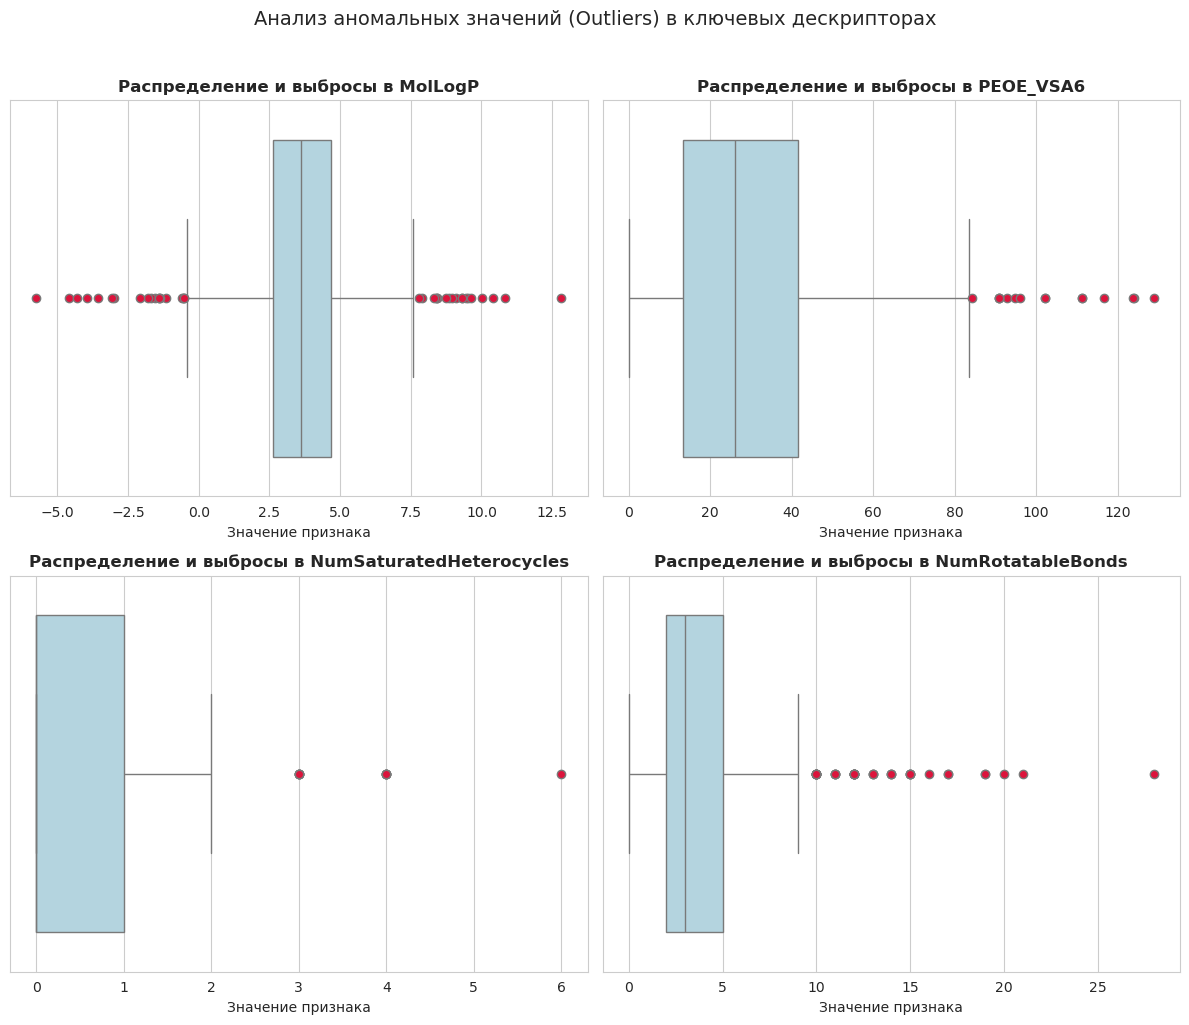

In [67]:
# Математический расчет выбросов по методу IQR
outliers_info = {}
for col in kept_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Считаем строки, выходящие за "усы"
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers_count > 0:
        outliers_info[col] = {
            'count': outliers_count,
            'percentage': (outliers_count / len(df)) * 100
        }

# Выведем общую статистику по выбросам
total_features_with_outliers = len(outliers_info)
print(f"Всего признаков с выбросами: {total_features_with_outliers} из {len(kept_features)}")

# Посмотрим на топ-5 признаков по числу аномалий
sorted_outliers = sorted(outliers_info.items(), key=lambda x: x[1]['count'], reverse=True)
print("\nТоп-10 признаков с наибольшим количеством выбросов:")
for name, stat in sorted_outliers[:10]:
    print(f" - {name}: {stat['count']} строк ({stat['percentage']:.1f}%)")

# 2. Визуализация "ящиков с усами" для 4-х ключевых признаков, влияющих на pIC50
# Возьмем те самые дескрипторы, которые вышли в топ на нашей матрице корреляции
plot_features = ['MolLogP', 'PEOE_VSA6', 'NumSaturatedHeterocycles', 'NumRotatableBonds']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, col in enumerate(plot_features):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue', flierprops=dict(markerfacecolor='crimson', marker='o'))
    axes[i].set_title(f'Распределение и выбросы в {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Значение признака')

fig.suptitle('Анализ аномальных значений (Outliers) в ключевых дескрипторах', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Анализ выбросов (Outliers) и стратегия масштабирования**

Проведен анализ признакового пространства на наличие аномальных значений с использованием метода межквартильного размаха ($IQR$). 

**Выводы анализа:**
1. Выбросы зафиксированы в значительной части физико-химических дескрипторов. Это обусловлено структурным разнообразием исследуемых химических соединений (наличием уникальных функциональных групп, редких гетероциклов или молекул с аномально большой массой).
2. **Стратегия обработки:** Принято решение **сохранить все строки с выбросами**, так как исключение уникальных химических структур критически снизит обобщающую способность моделей машинного обучения на реальных новых соединениях.
3. Чтобы минимизировать негативное влияние экстремальных значений на расчет весов (особенно в линейных моделях и нейросетях), на этапе предобработки перед обучением будет использован робастный метод масштабирования признаков — **`RobustScaler`**, который устойчив к выбросам, так как опирается на медиану и интерквартильный размах ($IQR$).


## Баланс классов

In [68]:
# Анализ баланса классов по всем задачам классификации

class_tasks = {
    'class_IC50_above_med': 'IC50 > Медианы',
    'class_CC50_above_med': 'CC50 > Медианы',
    'class_SI_above_med': 'SI > Медианы',
    'class_SI_above_8': 'SI > 8 (Соединения-лидеры)'
}

total_molecules = len(df)
print(f"=== ФИНАЛЬНЫЙ СТАТИСТИЧЕСКИЙ БАЛАНС КЛАССОВ ===")
print(f"Всего объектов в очищенной выборке: {total_molecules}\n")

for col, description in class_tasks.items():
    pos_count = df[col].sum()
    neg_count = total_molecules - pos_count
    
    pos_pct = (pos_count / total_molecules) * 100
    neg_pct = (neg_count / total_molecules) * 100
    
    print(f"Задача: {description} ({col})")
    print(f"  └─ Класс 0 (Нет): {neg_count} мол. ({neg_pct:.1f}%)")
    print(f"  └─ Класс 1 (Да) : {pos_count} мол. ({pos_pct:.1f}%)")
    print("-" * 50)


=== ФИНАЛЬНЫЙ СТАТИСТИЧЕСКИЙ БАЛАНС КЛАССОВ ===
Всего объектов в очищенной выборке: 802

Задача: IC50 > Медианы (class_IC50_above_med)
  └─ Класс 0 (Нет): 401 мол. (50.0%)
  └─ Класс 1 (Да) : 401 мол. (50.0%)
--------------------------------------------------
Задача: CC50 > Медианы (class_CC50_above_med)
  └─ Класс 0 (Нет): 401 мол. (50.0%)
  └─ Класс 1 (Да) : 401 мол. (50.0%)
--------------------------------------------------
Задача: SI > Медианы (class_SI_above_med)
  └─ Класс 0 (Нет): 401 мол. (50.0%)
  └─ Класс 1 (Да) : 401 мол. (50.0%)
--------------------------------------------------
Задача: SI > 8 (Соединения-лидеры) (class_SI_above_8)
  └─ Класс 0 (Нет): 533 мол. (66.5%)
  └─ Класс 1 (Да) : 269 мол. (33.5%)
--------------------------------------------------


**Финальный** аудит распределения классов подтверждает математическую структуру выборки:
* Задачи классификации по медианам (`IC50`, `CC50`, `SI`) имеют идеальный, строго симметричный баланс (~50% на 50%). Это гарантирует стабильное обучение стандартных классификаторов без смещения предсказаний.
* Целевая фармакологическая задача (`SI > 8`) демонстрирует выраженный дисбаланс классов. Это ключевой инсайт EDA, который обязывает нас использовать **стратифицированное разбиение данных** (`stratify`) и ориентироваться на робастные метрики качества (**F1-score**, **PR-AUC**) вместо базовой Accuracy.


# Отчёт по итогам EDA (Разведочный анализ данных)

Мы провели комплексную подготовку и глубокий анализ структуры датасета. Вот ключевые результаты и решения, которые легли в основу чистоты наших данных:

### 1. Очистка от технического брака и пропусков
* **Что нашли:** 3 строки (78, 79, 80) содержали пропуски (`NaN`) в критически важных дескрипторах зарядов и топологии. При этом строка 79 имела аномально высокую биологическую ценность ($SI \approx 74.63$), а строки 78 и 80 — экстремально ложные сигналы.
* **Решение:** Мы полностью удалили эти 3 строки. Потеря составляет **всего ~0.3% датасета**, но это застраховало модели от обучения на «химических Франкенштейнах» и ложных паттернах. Индексы таблицы были безопасно сброшены (`reset_index(drop=True)`), чтобы избежать сдвигов данных при работе с массивами NumPy.

### 2. Борьба с дубликатами и «близнецами»
* **Что нашли:** В датасете обнаружились **32 полных дубликата** и **196 повторяющихся молекул**, у которых химические признаки идентичны, а результаты биологических тестов (`IC50` и `CC50`) сильно отличаются из-за шума разных экспериментов.
* **Решение:** Полные дубликаты удалены. Для повторяющихся молекул мы применили **агрегацию через усреднение таргетов**. Это помогло сгладить лабораторный шум, не запутать модель противоречивыми ответами и сохранить для обучения почти 20% выборки. В итоге мы получили монолитную таблицу из **802 уникальных строк**.

### 3. Трансформация целевых переменных (Таргетов)
* **Что нашли:** Исходные непрерывные концентрации имели экстремальную асимметрию («тяжелые правые хвосты»), улетая в значения под 4000 мМ.
* **Решение:** Мы перевели `IC50` и `CC50` в отрицательный десятичный логарифм молярности (**pIC50** и **pCC50**), а `SI` — в обычный **log10(SI)**. Шкала сжалась до компактного диапазона (от 0 до 5), распределения стали близки к нормальному, что критически важно для стабильной работы регрессии. Отрицательные значения `pCC50` обоснованы химически и указывают на практически нетоксичные соединения.

### 4. Оптимизация признаков и корреляционный анализ
* **Что нашли:** Исходные 216 признаков содержали константный мусор и жесткую мультиколлинеарность (парную корреляцию вплоть до идеальных `1.0`). Например, масса и бензольные кольца дублировались разными дескрипторами.
* **Решение:** 
  * Мы точечно отфильтровали редкие фрагменты, удалив только те, что встречаются строго 1 раз на всю таблицу. Группы вроде гуанидина (`fr_guanido`) с частотой 2 были спасены.
  * Из пар признаков с корреляцией $> 0.90$ был удален один избыточный признак. Признаковое пространство сократилось с 216 до **157 чистых колонок**.
  * Анализ топ-признаков показал, что сильнее всего на активность (`pIC50`) влияют липофильность (`MolLogP`), полярная поверхность молекулы и её пространственная гибкость.

### 5. Анализ выбросов и дисбаланса классов
* **Что нашли:** Математический метод $IQR$ признал «выбросами» 139 из 147 признаков (особенно редкие функциональные группы вроде амидов и спиртов, так как у большинства молекул их просто нет). Также обнаружен сильный перекос в целевой фармакологической задаче классификации (`SI > 8`).
* **Стратегия для моделирования:** 
  1. Выбросы в признаках мы сохраняем насовсем, чтобы модель знала все химические группы. Но на этапе обучения мы обязательно используем **`RobustScaler`** (масштабирование по медиане и квантилям), чтобы эти хвосты не перекосили веса моделей.
  2. Из-за сильного смещения в задаче `SI > 8` мы отказываемся от метрики Accuracy в пользу **F1-score** и **PR-AUC**.
  3. Разделение выборки на Train/Test обязано быть **стратифицированным** (`stratify`), чтобы пропорции редкого класса лидеров сохранились в обеих частях.


# Сохранение результатов

In [69]:
# Сохранение очищенного датасета для последующего моделирования

# Используем index=False, чтобы Pandas не создавал лишнюю колонку с индексами при записи
df.to_csv('cleaned_chemical_data.csv', index=False)

print("Очищенный датасет сохранен в файл 'cleaned_chemical_data.csv'")
print(f"Финальные параметры таблицы: {df.shape[0]} строк, {df.shape[1]} колонок.")


Очищенный датасет сохранен в файл 'cleaned_chemical_data.csv'
Финальные параметры таблицы: 802 строк, 154 колонок.


# Заметки для понимания задания

## Биологический смысл параметров

* **$IC_{50}$ (Half-Maximal Inhibitory Concentration):** Концентрация вещества, которая подавляет определенную биологическую функцию, размножение возбудителя (вируса, бактерии) или активность фермента на $50\%$ по сравнению с контролем. Чем ниже значение $IC_{50}$, тем выше эффективность препарата.
* **$CC_{50}$ (Half-Maximal Cytotoxic Concentration):** Концентрация вещества, которая приводит к гибели $50\%$ здоровых клеток хозяина в условиях *in vitro*. Этот параметр характеризует базовую токсичность соединения. Чем выше $CC_{50}$, тем безопаснее вещество для клеток.
* **$SI$ (Selectivity Index):** Отношение токсической концентрации к эффективной ($SI = \frac{CC_{50}}{IC_{50}}$). Он показывает, насколько терапевтическая доза далека от токсической. Чем выше $SI$, тем селективнее препарат действует на мишень, не повреждая организм. Хорошим кандидатом считается вещество с $SI \geq 10$.

* **$IC_{50}$ (Сила препарата):** Сколько нужно лекарства, чтобы наполовину ($50\%$) подавить болезнь (вирус, бактерию). **Чем меньше цифра — тем лучше.**
* **$CC_{50}$ (Токсичность):** Сколько нужно лекарства, чтобы убить половину ($50\%$) здоровых клеток. **Чем больше цифра — тем лучше.**
* **$SI$ (Индекс безопасности):** Во сколько раз доза, убивающая клетки, больше дозы, убивающей болезнь ($CC_{50} / IC_{50}$). **Чем выше этот индекс — тем безопаснее лекарство.**

### Математические основы вычисления

Оба параметра — $IC_{50}$ и $CC_{50}$ — рассчитываются на основе **сигмоидальной кривой «доза — ответ»** (кривой Хилла). Зависимость эффекта от концентрации описывается нелинейным уравнением логистической регрессии.

#### Четырехпараметрическое логистическое уравнение (4PL):

$$Y = \text{Bottom} + \frac{\text{Top} - \text{Bottom}}{1 + 10^{(\log IC_{50} - X) \cdot p}}$$

Где:
* $Y$ — измеряемый ответ (например, % ингибирования или % выживаемости клеток).
* $X$ — десятичный логарифм концентрации вещества ($\log C$).
* $\text{Top}$ — максимальный plateau-эффект (обычно $100\%$ контроля).
* $\text{Bottom}$ — минимальный plateau-эффект (обычно $0\%$).
* $p$ — коэффициент Хилла (Hill slope), определяющий крутизну изгиба кривой.
* $IC_{50}$ — искомая концентрация в точке полумаксимального эффекта.

Если данные нормализованы от $0$ до $100\%$, уравнение Хилла упрощается до стандартного логистического вида:

$$Y = \frac{100}{1 + \left(\frac{IC_{50}}{C}\right)^p}$$

#### Математический вывод логарифмического графика (Преобразование logit-log):

$$\ln\left(\frac{Y}{100 - Y}\right) = p \cdot \ln(C) - p \cdot \ln(IC_{50})$$

### Расчет индекса селективности (SI)

Математическая формула $SI$ представляет собой линейное отношение:

$$SI = \frac{CC_{50}}{IC_{50}}$$

Разница между эффективностью и токсичностью на логарифмическом графике математически равна расстоянию между двумя сигмоидами по оси абсцисс $\log X$:

$$\log_{10}(SI) = \log_{10}(CC_{50}) - \log_{10}(IC_{50})$$

#### Пример интерпретации значений:

| Значение $SI$ | Оценка безопасности препарата | Действие |
| :--- | :--- | :--- |
| **$SI < 1$** | Препарат убивает клетки быстрее, чем патоген. | Бракуется |
| **$1 < SI < 10$** | Низкая избирательность, высокий риск побочных эффектов. | Требует модификации |
| **$SI \geq 10$** | Хорошее терапевтическое окно, высокая селективность. | Допускается к *in vivo* |

#### Интерпретация в шкале pIC_50 и pCC_50

В логарифмической шкале индекс безопасности рассчитывается через разность:
$$\log_{10}(SI) = pIC_{50} - pCC_{50}$$

* **Как оценивать:** Чем сильнее $pIC_{50}$ превышает $pCC_{50}$, тем безопаснее соединение.
* **Критерий отбора ($SI \geq 10$):** Значение $pIC_{50}$ должно быть **минимум на 1 единицу больше**, чем $pCC_{50}$. 
* **Пример:** Если $pIC_{50} = 7$, а $pCC_{50} = 5$, то разница равна $2$. Значит, $SI = 10^2 = 100$ (вещество очень безопасное).

## Перспективная архитектура: Многозадачное обучение (Multi-Task Learning / MTL)

В качестве вектора дальнейшего развития проекта предлагается переход от изолированных классических моделей к единой архитектуре глубокого многозадачного обучения (**MTL**).

* **Суть подхода:** Вместо обучения независимых алгоритмов создается единая нейросетевая модель с общими скрытыми слоями и двумя раздельными выходными «головами» для одновременного предсказания активности ($pIC_{50}$) и токсичности ($pCC_{50}$).
* **Преимущества для задачи:**
  * **Учет биологического контекста:** Общие слои сети извлекают универсальные химические паттерны, заставляя модель использовать скрытые взаимосвязи между терапевтическим эффектом и клеточной гибелью.
  * **Регуляризация:** Одновременное обучение двум смежным задачам выступает в роли естественного барьера против переобучения (overfitting).
  * **Обработка пропусков:** Архитектура MTL способна эффективно обучаться на частично размеченных экспериментальных данных, когда для молекулы известен только один из параметров.
* **Расчет селективности:** Показатель $SI$ в данном сценарии также остается расчетной производной величиной, вычисляемой на этапе постобработки по формуле $\log_{10}(SI) = pIC_{50} - pCC_{50}$.
